In [11]:
import polars as pl

# 1.crée le LazyFrame
lazy_car = pl.scan_csv('D:/Analyse_car/data/raw/car_prices.csv', ignore_errors=True)

# 2.prépare une transformation (sans l'exécuter encore)
lazy_plan = lazy_car.with_columns(pl.col("make").str.to_uppercase())

In [12]:
# "cuisine" le plan pour obtenir les données réelles
df_clean = lazy_plan.collect()

# utiliser des fonctions de diagnostic rapides
print(df_clean.head(3))
print(f"Nombre de lignes chargées : {df_clean.height}")

shape: (3, 16)
┌──────┬──────┬──────────┬────────────┬───┬────────────────┬───────┬──────────────┬────────────────┐
│ year ┆ make ┆ model    ┆ trim       ┆ … ┆ seller         ┆ mmr   ┆ sellingprice ┆ saledate       │
│ ---  ┆ ---  ┆ ---      ┆ ---        ┆   ┆ ---            ┆ ---   ┆ ---          ┆ ---            │
│ i64  ┆ str  ┆ str      ┆ str        ┆   ┆ str            ┆ i64   ┆ i64          ┆ str            │
╞══════╪══════╪══════════╪════════════╪═══╪════════════════╪═══════╪══════════════╪════════════════╡
│ 2015 ┆ KIA  ┆ Sorento  ┆ LX         ┆ … ┆ kia motors     ┆ 20500 ┆ 21500        ┆ Tue Dec 16     │
│      ┆      ┆          ┆            ┆   ┆ america  inc   ┆       ┆              ┆ 2014 12:30:00  │
│      ┆      ┆          ┆            ┆   ┆                ┆       ┆              ┆ GMT-0…         │
│ 2015 ┆ KIA  ┆ Sorento  ┆ LX         ┆ … ┆ kia motors     ┆ 20800 ┆ 21500        ┆ Tue Dec 16     │
│      ┆      ┆          ┆            ┆   ┆ america  inc   ┆       ┆        

In [13]:
# On transforme le DataFrame en LazyFrame pour préparer un gros calcul
resultat_final = (
    df_clean.lazy()
    .group_by("make")
    .agg([
        pl.col("sellingprice").mean().alias("prix_moyen"),
        pl.col("odometer").median().alias("km_median")
    ])
    .sort("prix_moyen", descending=True)
    .collect() # On récupère juste le petit tableau de résultat
)

print(resultat_final.head(10))

shape: (10, 3)
┌──────────────┬───────────────┬───────────┐
│ make         ┆ prix_moyen    ┆ km_median │
│ ---          ┆ ---           ┆ ---       │
│ str          ┆ f64           ┆ f64       │
╞══════════════╪═══════════════╪═══════════╡
│ ROLLS-ROYCE  ┆ 153488.235294 ┆ 12601.0   │
│ FERRARI      ┆ 127210.526316 ┆ 12116.0   │
│ LAMBORGHINI  ┆ 112625.0      ┆ 19153.0   │
│ BENTLEY      ┆ 74367.672414  ┆ 35614.0   │
│ AIRSTREAM    ┆ 71000.0       ┆ 51971.0   │
│ TESLA        ┆ 67054.347826  ┆ 15854.0   │
│ ASTON MARTIN ┆ 54812.0       ┆ 23968.0   │
│ FISKER       ┆ 46461.111111  ┆ 14740.0   │
│ MASERATI     ┆ 44947.058824  ┆ 26641.0   │
│ LOTUS        ┆ 40800.0       ┆ 16932.0   │
└──────────────┴───────────────┴───────────┘


In [10]:
import polars as pl

# 1. Chargement Lazy
lazy_df = pl.scan_csv('D:/Analyse_car/data/raw/car_prices.csv', infer_schema_length=10000, ignore_errors=True)

# 2. Diagnostic SANS avertissement
# Au lieu de .schema, on utilise .collect_schema()
print("--- Structure des colonnes (Schema) ---")
print(lazy_df.collect_schema())

# 3. Compter les nulls (Exécution du plan)
print("\n--- Valeurs manquantes ---")
null_counts = lazy_df.null_count().collect()
print(null_counts)

--- Structure des colonnes (Schema) ---
Schema({'year': Int64, 'make': String, 'model': String, 'trim': String, 'body': String, 'transmission': String, 'vin': String, 'state': String, 'condition': Int64, 'odometer': Int64, 'color': String, 'interior': String, 'seller': String, 'mmr': Int64, 'sellingprice': Int64, 'saledate': String})

--- Valeurs manquantes ---
shape: (1, 16)
┌──────┬───────┬───────┬───────┬───┬────────┬─────┬──────────────┬──────────┐
│ year ┆ make  ┆ model ┆ trim  ┆ … ┆ seller ┆ mmr ┆ sellingprice ┆ saledate │
│ ---  ┆ ---   ┆ ---   ┆ ---   ┆   ┆ ---    ┆ --- ┆ ---          ┆ ---      │
│ u32  ┆ u32   ┆ u32   ┆ u32   ┆   ┆ u32    ┆ u32 ┆ u32          ┆ u32      │
╞══════╪═══════╪═══════╪═══════╪═══╪════════╪═════╪══════════════╪══════════╡
│ 0    ┆ 10301 ┆ 10399 ┆ 10651 ┆ … ┆ 0      ┆ 38  ┆ 12           ┆ 12       │
└──────┴───────┴───────┴───────┴───┴────────┴─────┴──────────────┴──────────┘


In [8]:
import polars as pl

# 1. Charger en mode Lazy (efficace pour les gros fichiers)
lazy_df = pl.scan_csv('D:/Analyse_car/data/raw/car_prices.csv', infer_schema_length=10000, ignore_errors=True)

# 2. IMPORTANT : Pour analyser les données, il faut "collecter" les résultats
# On transforme le plan de calcul (Lazy) en données réelles (DataFrame)
exploration_df = lazy_df.collect()

# 3. Maintenant, votre analyse sur les marques fonctionnera parfaitement
brand_counts = (
    exploration_df
    .group_by("make")
    .agg(pl.len().alias("count"))
    .sort("count", descending=True)
    .head(10)
)

print("Top 10 des marques :")
print(brand_counts)

Top 10 des marques :
shape: (10, 2)
┌───────────┬───────┐
│ make      ┆ count │
│ ---       ┆ ---   │
│ str       ┆ u32   │
╞═══════════╪═══════╡
│ Ford      ┆ 93554 │
│ Chevrolet ┆ 60197 │
│ Nissan    ┆ 53946 │
│ Toyota    ┆ 39871 │
│ Dodge     ┆ 30710 │
│ Honda     ┆ 27206 │
│ Hyundai   ┆ 21816 │
│ BMW       ┆ 20719 │
│ Kia       ┆ 18077 │
│ Chrysler  ┆ 17276 │
└───────────┴───────┘


In [9]:
# Compter les valeurs nulles (Sur les 558 837 lignes)
null_counts = lazy_df.null_count().collect()
print(null_counts)

# Vérifier le type des colonnes (Le plan de travail)
print(lazy_df.schema)

shape: (1, 16)
┌──────┬───────┬───────┬───────┬───┬────────┬─────┬──────────────┬──────────┐
│ year ┆ make  ┆ model ┆ trim  ┆ … ┆ seller ┆ mmr ┆ sellingprice ┆ saledate │
│ ---  ┆ ---   ┆ ---   ┆ ---   ┆   ┆ ---    ┆ --- ┆ ---          ┆ ---      │
│ u32  ┆ u32   ┆ u32   ┆ u32   ┆   ┆ u32    ┆ u32 ┆ u32          ┆ u32      │
╞══════╪═══════╪═══════╪═══════╪═══╪════════╪═════╪══════════════╪══════════╡
│ 0    ┆ 10301 ┆ 10399 ┆ 10651 ┆ … ┆ 0      ┆ 38  ┆ 12           ┆ 12       │
└──────┴───────┴───────┴───────┴───┴────────┴─────┴──────────────┴──────────┘
Schema({'year': Int64, 'make': String, 'model': String, 'trim': String, 'body': String, 'transmission': String, 'vin': String, 'state': String, 'condition': Int64, 'odometer': Int64, 'color': String, 'interior': String, 'seller': String, 'mmr': Int64, 'sellingprice': Int64, 'saledate': String})


C:\Users\lahatra\AppData\Local\Temp\ipykernel_6520\739249113.py:6: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  print(lazy_df.schema)


importe le code dans le data_cleaning.py vers ici


In [17]:
import sys
import os

# 1. On ajoute le dossier 'src' au chemin de recherche de Python
sys.path.append(os.path.abspath('D:/Analyse_car/src'))

# 2. On importe TA fonction comme une bibliothèque officielle
from data_cleaning import charger_et_nettoyer

# 3. Utilisation directe
df = charger_et_nettoyer('D:/Analyse_car/data/raw/car_prices.csv')
print(df.head())

naive plan: (run LazyFrame.explain(optimized=True) to see the optimized plan)

SLICE[offset: 0, len: 5]
   WITH_COLUMNS:
   [col("year"), col("make"), col("model"), col("trim"), col("body"), col("transmission"), col("vin"), col("state"), col("condition"), col("odometer"), col("color"), col("interior"), col("seller"), col("mmr"), col("sellingprice"), col("saledate")] 
    FILTER col("saledate").is_not_null()
    FROM
      FILTER col("sellingprice").is_not_null()
      FROM
        FILTER col("mmr").is_not_null()
        FROM
          FILTER col("seller").is_not_null()
          FROM
            FILTER col("interior").is_not_null()
            FROM
              FILTER col("color").is_not_null()
              FROM
                FILTER col("odometer").is_not_null()
                FROM
                  FILTER col("condition").is_not_null()
                  FROM
                    FILTER col("state").is_not_null()
                    FROM
                      FILTER col("vin").is_n

utilise le script dans datacleaning

In [19]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration du style des graphiques
sns.set_theme(style="whitegrid")

In [20]:
# Chargement du fichier déjà traité (Propre et Rapide)
df = pl.read_parquet('D:/Analyse_car/data/cleaned/car_prices_clean.parquet')

print(f"Données chargées : {df.height} lignes et {df.width} colonnes.")
print(df.head(3))

Données chargées : 472325 lignes et 16 colonnes.
shape: (3, 16)
┌──────┬──────┬──────────┬────────────┬───┬────────────────┬───────┬──────────────┬────────────────┐
│ year ┆ make ┆ model    ┆ trim       ┆ … ┆ seller         ┆ mmr   ┆ sellingprice ┆ saledate       │
│ ---  ┆ ---  ┆ ---      ┆ ---        ┆   ┆ ---            ┆ ---   ┆ ---          ┆ ---            │
│ i64  ┆ str  ┆ str      ┆ str        ┆   ┆ str            ┆ i64   ┆ i64          ┆ str            │
╞══════╪══════╪══════════╪════════════╪═══╪════════════════╪═══════╪══════════════╪════════════════╡
│ 2015 ┆ Kia  ┆ Sorento  ┆ LX         ┆ … ┆ kia motors     ┆ 20500 ┆ 21500        ┆ Tue Dec 16     │
│      ┆      ┆          ┆            ┆   ┆ america  inc   ┆       ┆              ┆ 2014 12:30:00  │
│      ┆      ┆          ┆            ┆   ┆                ┆       ┆              ┆ GMT-0…         │
│ 2015 ┆ Kia  ┆ Sorento  ┆ LX         ┆ … ┆ kia motors     ┆ 20800 ┆ 21500        ┆ Tue Dec 16     │
│      ┆      ┆          ┆ 

C:\Users\lahatra\AppData\Local\Temp\ipykernel_6520\2131906297.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_brands.to_pandas(), x="make", y="volume_ventes", palette="viridis")


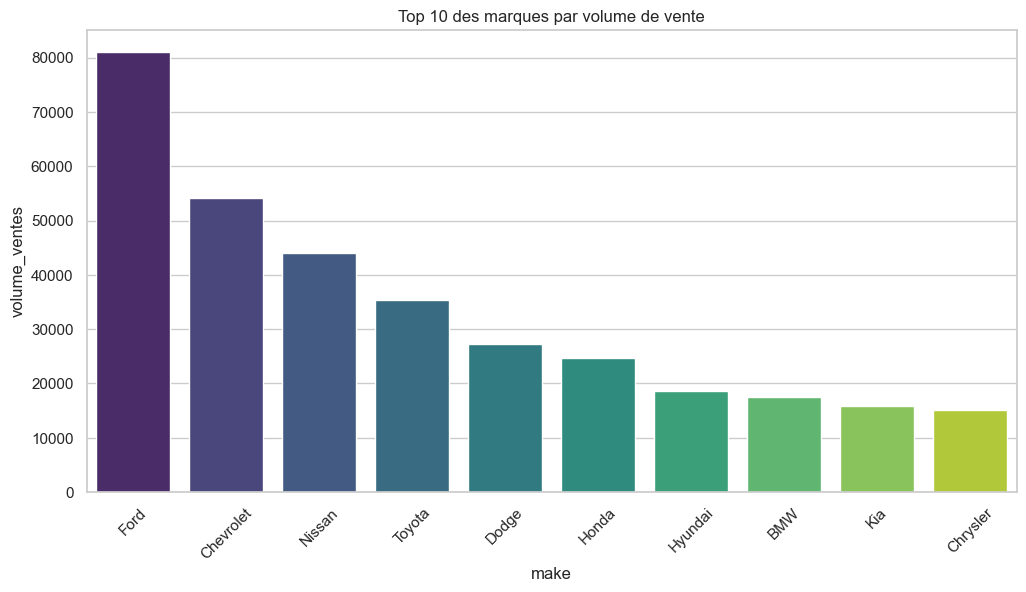

In [21]:
# Top 10 des marques les plus vendues
top_brands = (
    df.group_by("make")
    .agg(pl.len().alias("volume_ventes"))
    .sort("volume_ventes", descending=True)
    .head(10)
)

# Visualisation simple
plt.figure(figsize=(12, 6))
sns.barplot(data=top_brands.to_pandas(), x="make", y="volume_ventes", palette="viridis")
plt.title("Top 10 des marques par volume de vente")
plt.xticks(rotation=45)
plt.show()